In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

In [2]:
# remove top and right spines for all plots in matplotlib params
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

## Discourse page views

In [3]:
# read csv file
filename = "consolidated-page-views-260303-145719.csv"
discourse_page_views = pd.read_csv(filename)

In [4]:
discourse_page_views.head()

,Day,Logged in users,Anonymous users,Crawlers
0,2023-11-23,41.0,9.0,NaN
1,2023-11-24,15.0,5.0,2.0
2,2023-11-26,1.0,18.0,NaN
3,2023-11-27,75.0,25.0,1.0
4,2023-11-28,92.0,41.0,1.0


In [5]:
# convert 'Day' to datetime
discourse_page_views["Day"] = pd.to_datetime(discourse_page_views["Day"])

In [6]:
# group per month (sum numeric columns only)
discourse_page_views_monthly = discourse_page_views.groupby(
    discourse_page_views["Day"].dt.to_period("M")
)[["Logged in users", "Anonymous users", "Crawlers"]].sum()
# name the index for clarity
discourse_page_views_monthly.index.name = "Month"

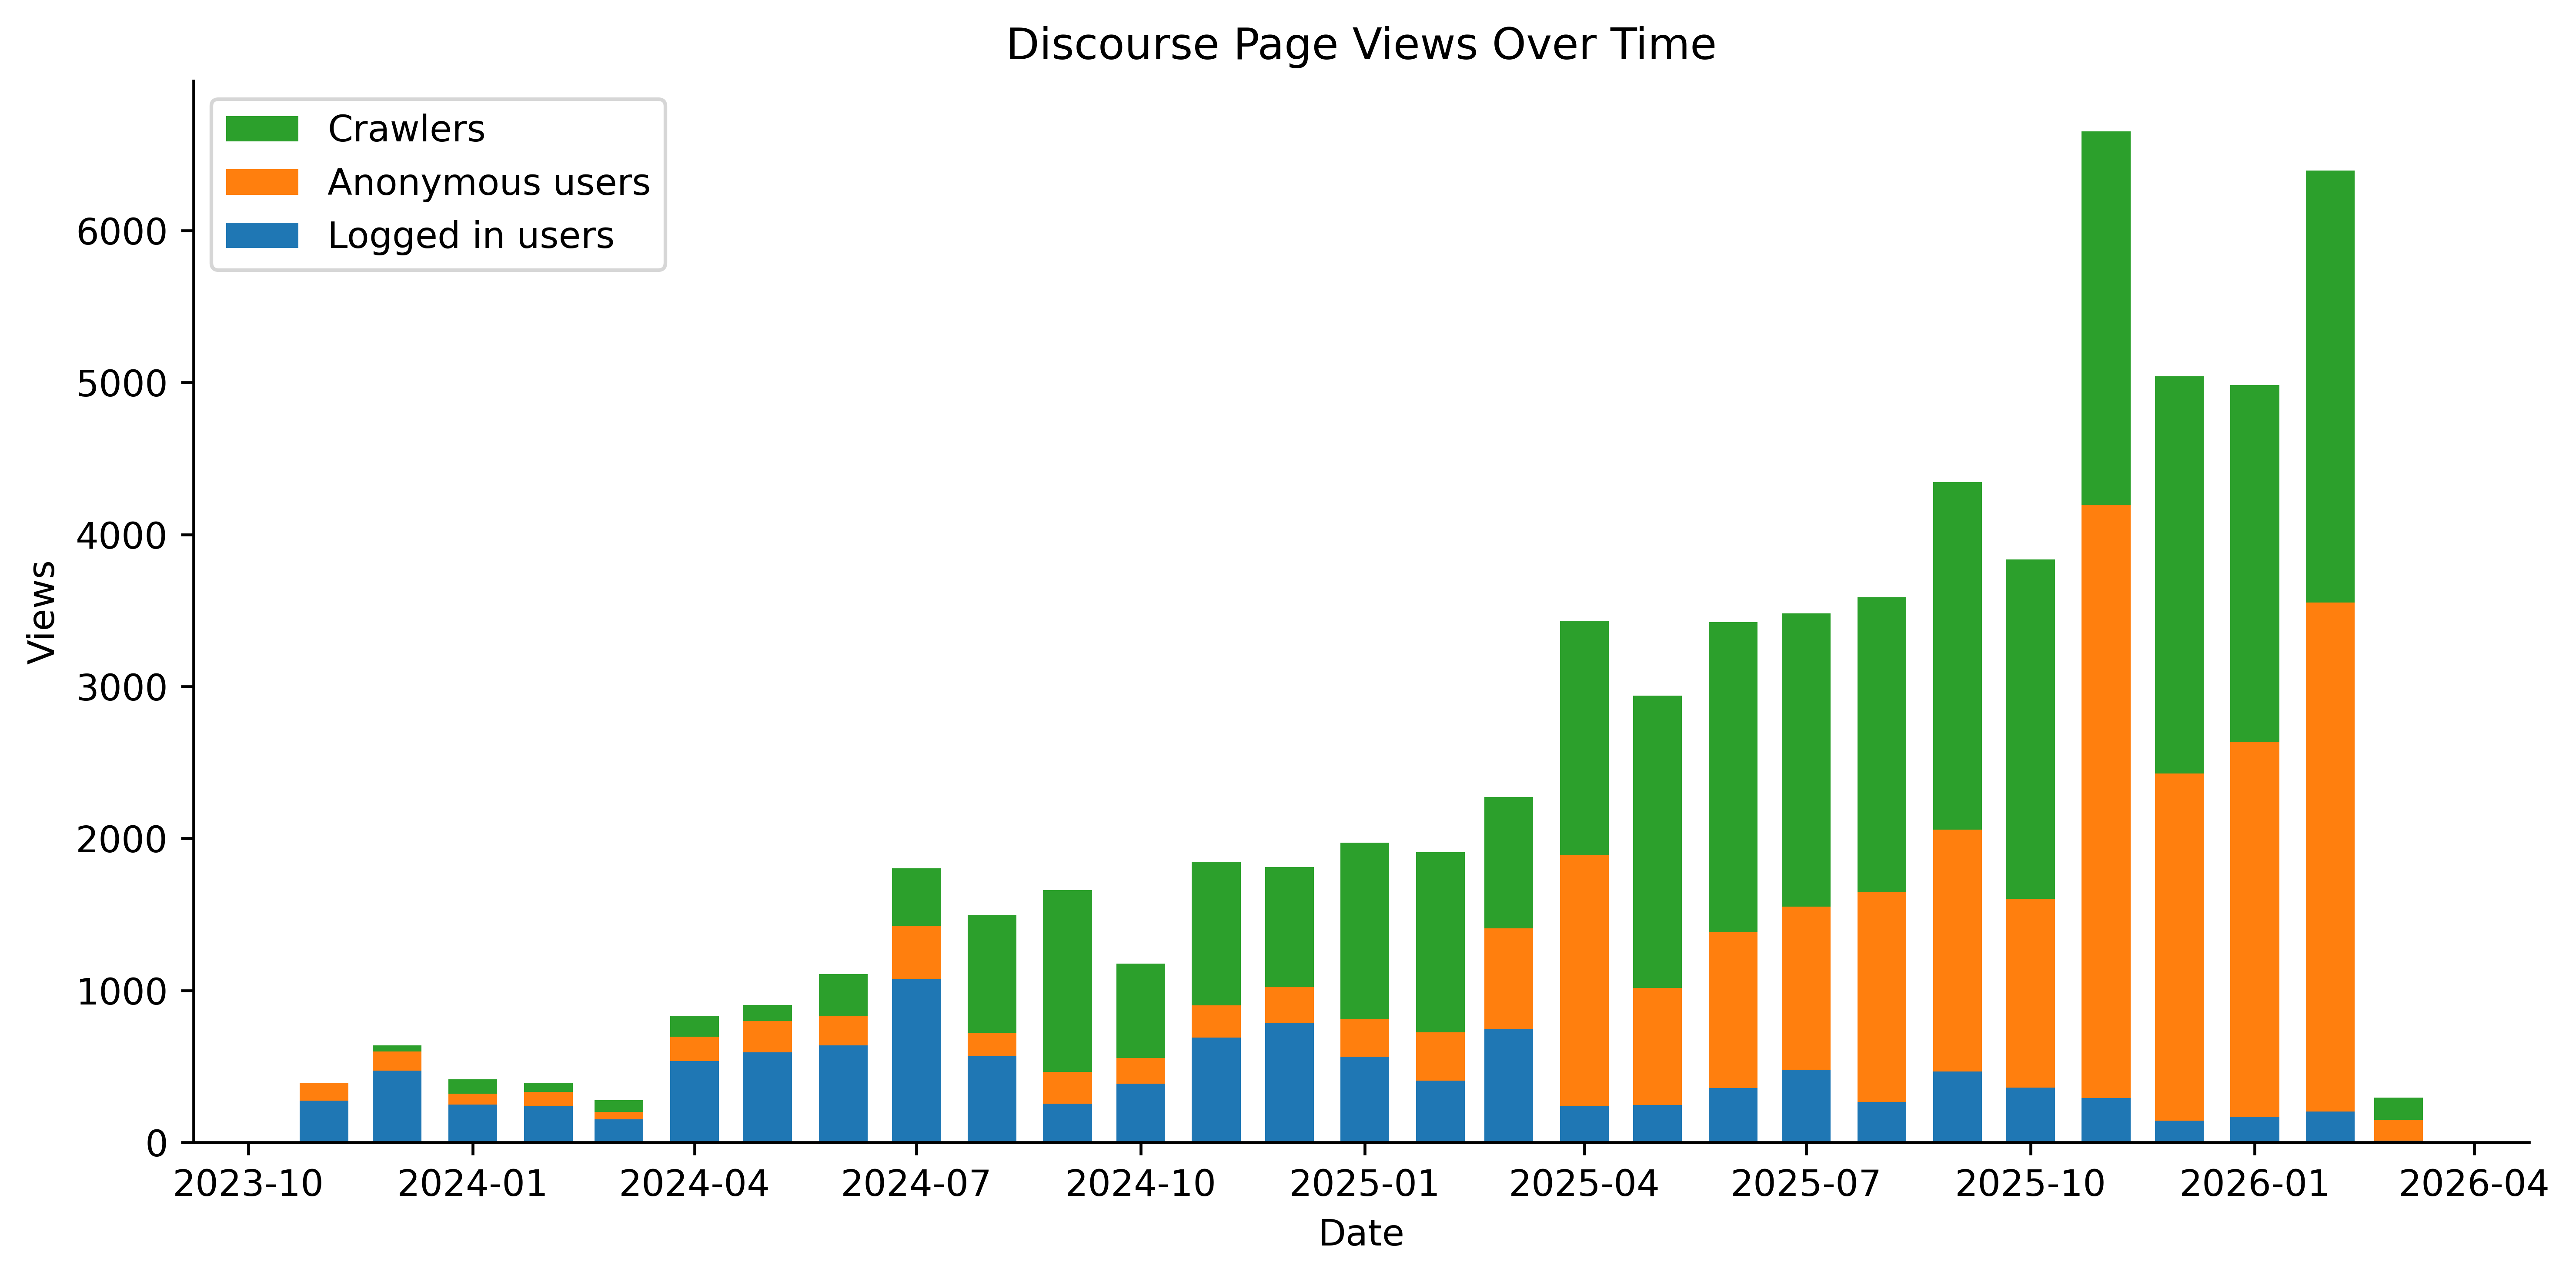

In [7]:
import matplotlib.pyplot as plt


def plot_page_views(width=20):
    x = (
        discourse_page_views_monthly.index.to_timestamp()
        if hasattr(discourse_page_views_monthly.index, "to_timestamp")
        else discourse_page_views_monthly.index
    )
    plt.bar(
        x,
        discourse_page_views_monthly["Logged in users"],
        label="Logged in users",
        width=width,
    )
    plt.bar(
        x,
        discourse_page_views_monthly["Anonymous users"],
        bottom=discourse_page_views_monthly["Logged in users"],
        label="Anonymous users",
        width=width,
    )
    plt.bar(
        x,
        discourse_page_views_monthly["Crawlers"],
        bottom=discourse_page_views_monthly["Logged in users"]
        + discourse_page_views_monthly["Anonymous users"],
        label="Crawlers",
        width=width,
    )


plt.figure(dpi=600, figsize=(10, 5))

# plot the data - convert PeriodIndex to timestamps for plotting
plot_page_views(width=20)
plt.title("Discourse Page Views Over Time")
plt.xlabel("Date")
plt.ylabel("Views")
plt.legend(reverse=True)
plt.tight_layout()
plt.show()

## Discourse signups

In [8]:
# read csv file
filename = "signups-260303-170440.csv"
discourse_signups = pd.read_csv(filename)
discourse_signups.head()

,Day,Count
0,2023-11-23,1
1,2023-11-27,3
2,2023-12-04,1
3,2023-12-05,1
4,2023-12-13,1


In [9]:
# convert 'Day' to datetime
discourse_signups["Day"] = pd.to_datetime(discourse_signups["Day"])

# group per month (sum numeric columns only)
discourse_signups_monthly = discourse_signups.groupby(
    discourse_signups["Day"].dt.to_period("M")
)
discourse_signups_monthly = discourse_signups_monthly[["Count"]].sum()

In [10]:
discourse_signups_monthly

,Count
Day,
2023-11,4
2023-12,3
2024-01,1
2024-04,3
2024-05,3
2024-06,1
2024-07,5
2024-08,2
2024-09,1


/tmp/ipykernel_403393/3905636335.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(reverse=True)


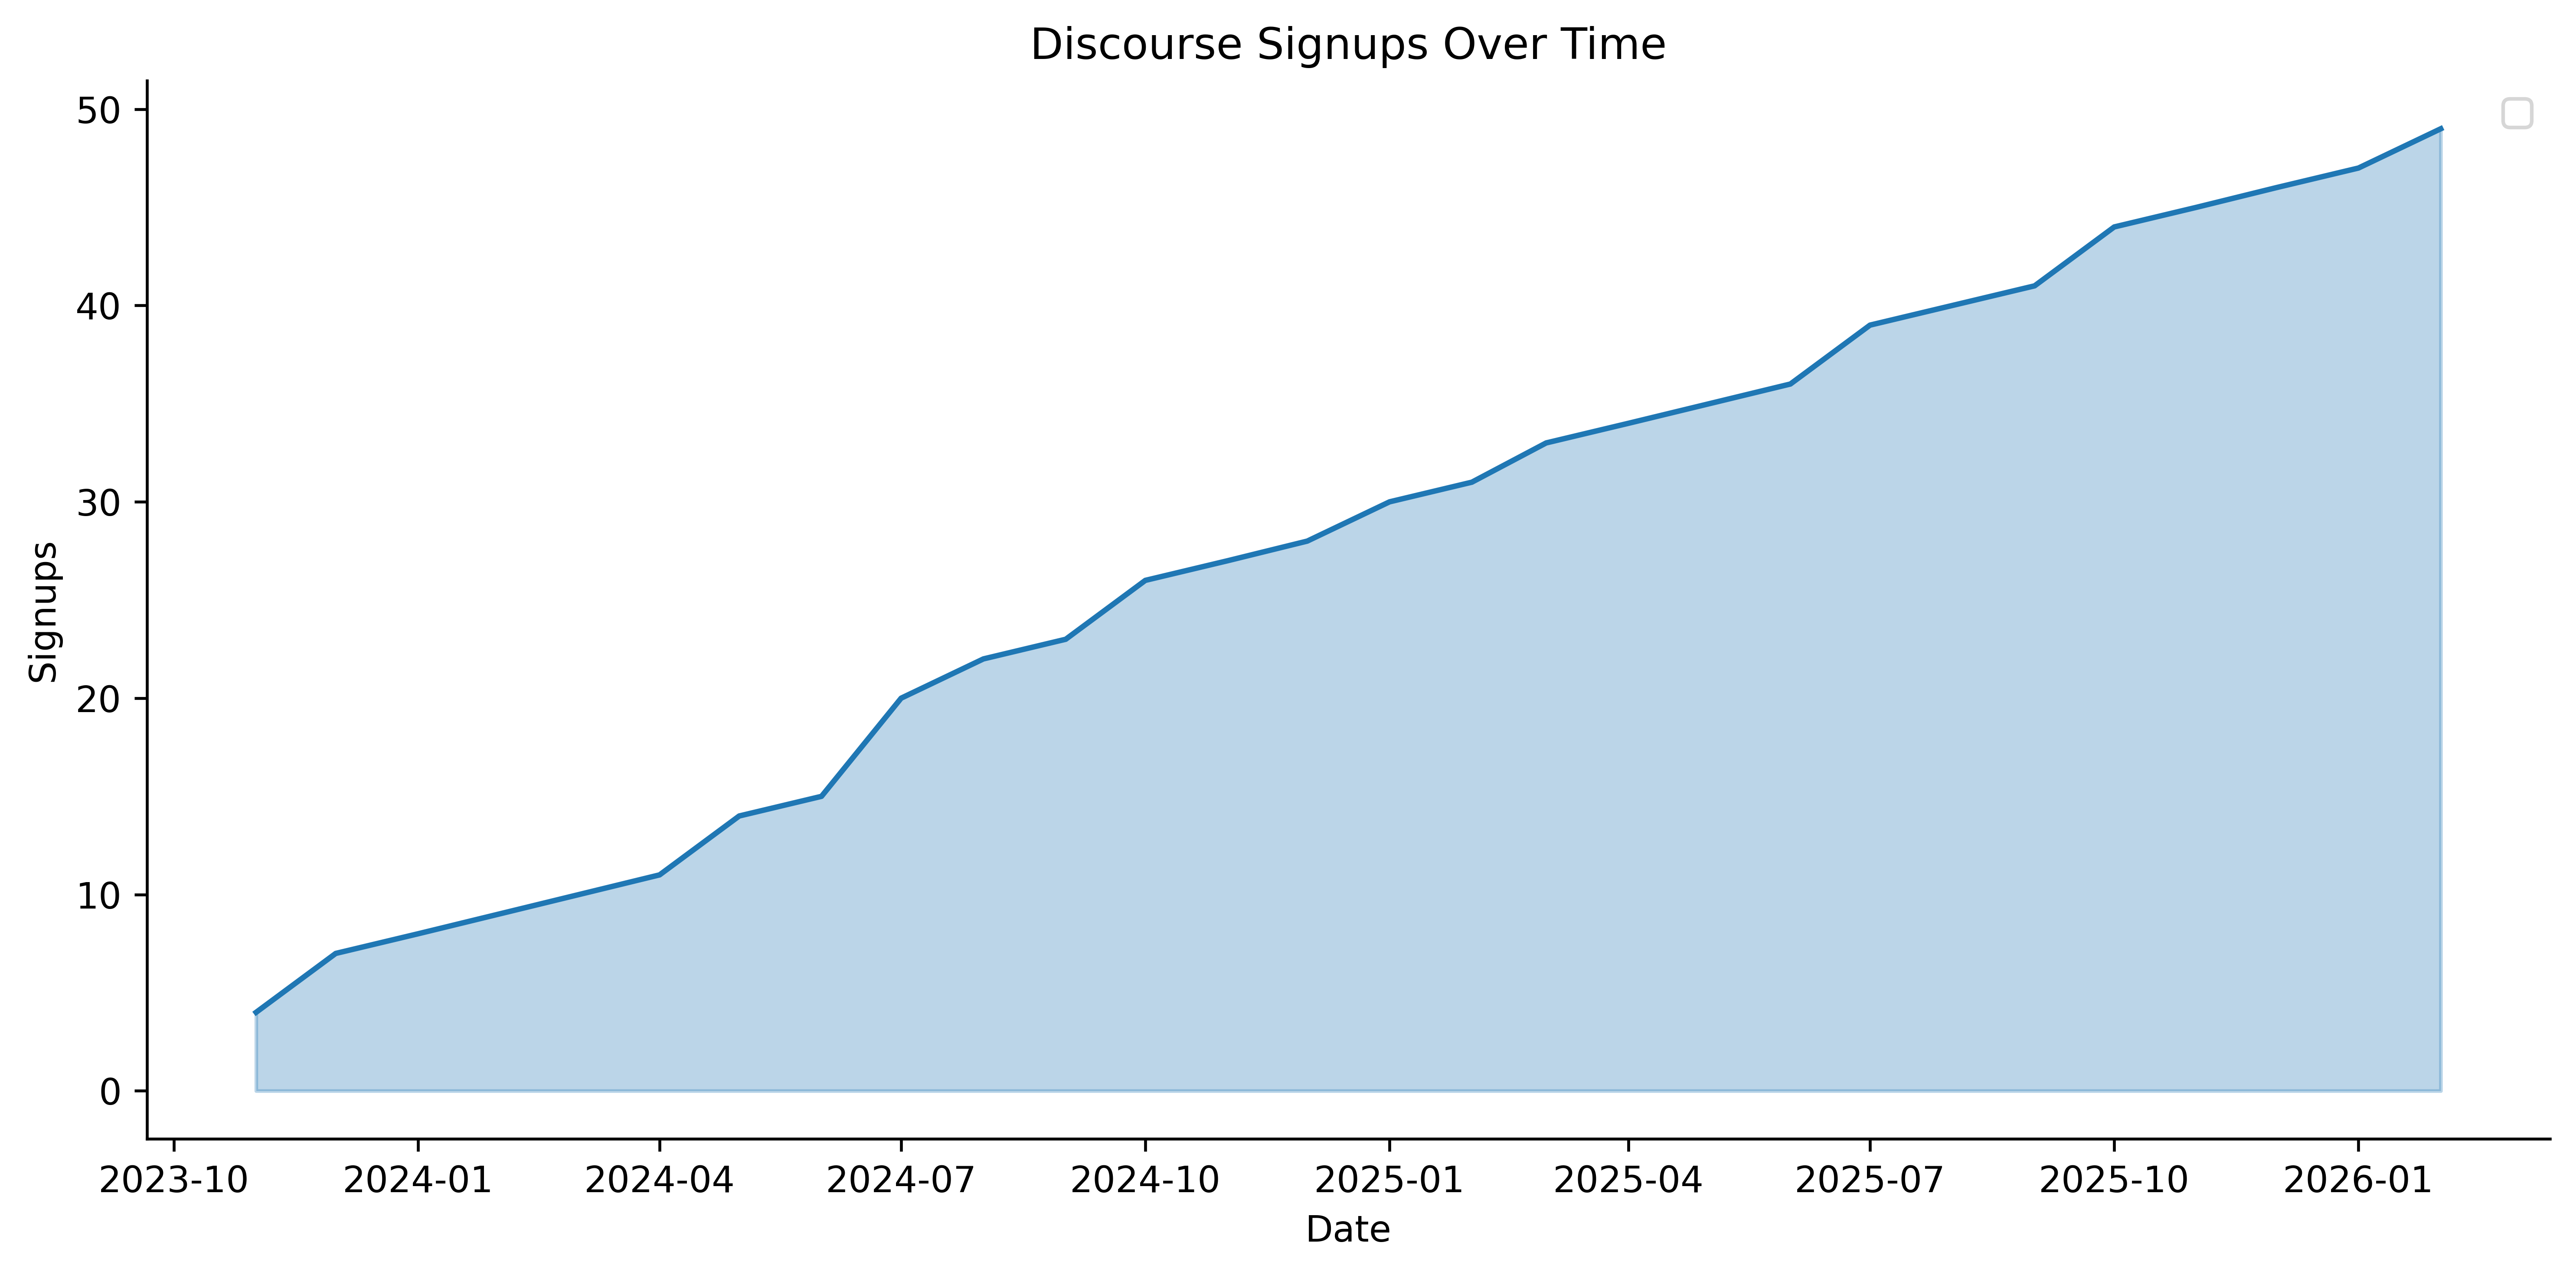

In [11]:

# name the index for clarity
discourse_signups_monthly.index.name = "Month"

def plot_signups(fill_betwee=True, **kwargs):
    x = (
        discourse_signups_monthly.index.to_timestamp()
        if hasattr(discourse_signups_monthly.index, "to_timestamp")
        else discourse_signups_monthly.index
    )
    cumulative_signups = discourse_signups_monthly["Count"].cumsum()
    l, = plt.plot(x, cumulative_signups, **kwargs)
    if fill_betwee:
        plt.fill_between(x, cumulative_signups, alpha=0.3, color=l.get_color())
    
    return x, cumulative_signups

plt.figure(dpi=600, figsize=(10, 5))

# plot the data - convert PeriodIndex to timestamps for plotting
plot_signups()
plt.title("Discourse Signups Over Time")
plt.xlabel("Date")
plt.ylabel("Signups")
plt.legend(reverse=True)
plt.tight_layout()
plt.show()

## Star history

In [12]:
import requests

OWNER = "festim-dev"
REPO = "festim"


url = f"https://api.github.com/repos/{OWNER}/{REPO}/stargazers"
headers = {
    "Accept": "application/vnd.github.v3.star+json",
    # "Authorization": f"Bearer {TOKEN}",  # uncomment for higher rate limits
}
page = 1
all_stars = []
while True:
    url = f"https://api.github.com/repos/{OWNER}/{REPO}/stargazers"
    # NOTE there seems to be a limit of 100 per page, so we need to paginate through the results
    response = requests.get(
        url, headers=headers, params={"per_page": 100, "page": page}
    )
    data = response.json()

    if not data:
        break

    all_stars.extend(data)
    page += 1

In [13]:
# Each item now has "starred_at" and "user"
for star in all_stars:
    print(star["starred_at"], star["user"]["login"])

2021-12-13T20:33:01Z mougenj
2022-07-27T12:22:30Z stephen-dixon
2022-07-27T12:34:14Z shimwell
2022-07-27T12:42:03Z jhillairet
2022-07-27T13:30:40Z BilelJegham
2022-07-27T13:44:39Z tianyikillua
2022-07-27T18:36:04Z giovanni-mariano
2022-08-08T22:30:23Z tkoyama010
2022-08-12T11:52:39Z StephDlpmtn
2022-08-12T23:59:54Z pshriwise
2022-08-19T06:58:50Z tengfeideng
2022-08-29T13:12:55Z ehodille
2022-09-13T15:36:45Z MKastek
2022-09-29T07:30:47Z liliangillier
2022-10-23T08:21:00Z husni-zuhdi
2022-12-13T22:51:24Z jlogan-cfs
2022-12-14T16:29:29Z lcarasik
2023-01-10T00:15:43Z george-poole
2023-06-21T06:59:44Z XuesenYang
2023-07-09T12:14:02Z FranFani
2023-07-09T12:31:20Z DinushaJ
2023-07-09T14:12:28Z FuerstT
2023-07-09T15:41:32Z PXC998
2023-07-09T15:41:38Z jehbice
2023-07-09T15:41:46Z niamh-holland
2023-07-09T15:41:47Z steven-van-boxel
2023-07-09T15:41:49Z zhengs-cn
2023-07-09T15:41:51Z AMPechero
2023-07-09T15:41:57Z odvorak89
2023-07-09T15:42:15Z LukeFisherUKAEA
2023-07-09T15:42:18Z AKI-1997
2023-0

In [14]:
from numpy import cumsum
from datetime import datetime

# Convert "starred_at" to datetime and sort
star_dates = sorted(
    [datetime.strptime(star["starred_at"], "%Y-%m-%dT%H:%M:%SZ") for star in all_stars]
)
# Create a cumulative count of stars over time
cumulative_stars = cumsum([1] * len(star_dates))

Text(0, 0.5, 'Cumulative Stars')

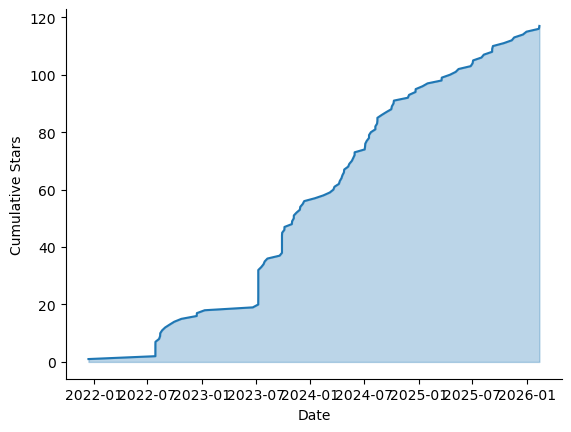

In [15]:
import matplotlib.pyplot as plt


def plot_star_history(fillbetween=True):
    (l,) = plt.plot(star_dates, cumulative_stars)
    if fillbetween:
        plt.fill_between(star_dates, cumulative_stars, alpha=0.3, color=l.get_color())

    return l

plot_star_history()
plt.xlabel("Date")
plt.ylabel("Cumulative Stars")

## User workshops

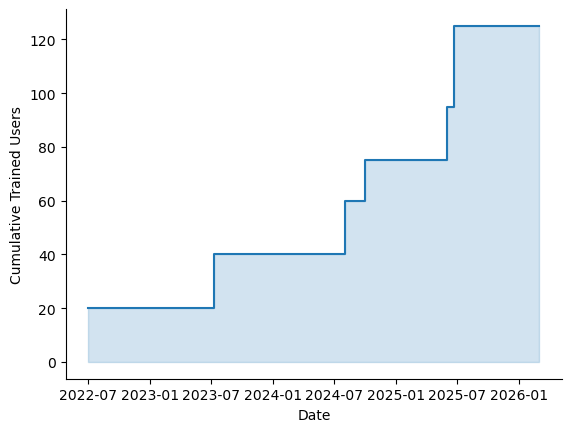

In [16]:
import numpy as np

workshop_data = [
    {
        "name": "SOFE 2025",
        "date": datetime(2025, 6, 23),
        "attendees": 30,
    },
    {
        "name": "SOFE 2023",
        "date": datetime(2023, 7, 9),
        "attendees": 20,
    },
    {
        "name": "CEA LMJ",
        "date": datetime(2025, 6, 1),
        "attendees": 20,
    },
    {
        "name": "UKAEA",
        "date": datetime(2024, 8, 1),
        "attendees": 20,
    },
    {
        "name": "IPP Garching",
        "date": datetime(2024, 9, 30),
        "attendees": 15,
    },
    {
        "name": "Kyoto Fusioneering",
        "date": datetime(2022, 7, 1),
        "attendees": 20,
    },
]


def plot_trained_users_over_time(workshop_data, fill_between=True):
    _workshop_data = sorted(workshop_data, key=lambda x: x["date"])

    cumulative_trained_users = np.cumsum(
        [workshop["attendees"] for workshop in _workshop_data]
    )
    workshop_dates = [workshop["date"] for workshop in _workshop_data]

    # add today with the latest number
    workshop_dates.append(datetime.today())
    cumulative_trained_users = np.append(
        cumulative_trained_users, cumulative_trained_users[-1]
    )

    l, = plt.step(workshop_dates, cumulative_trained_users, where="post")
    if fill_between:
        plt.fill_between(
            workshop_dates,
            cumulative_trained_users,
            step="post",
            alpha=0.2,
            color=l.get_color(),
        )

    return workshop_dates, cumulative_trained_users


plt.figure()
plot_trained_users_over_time(workshop_data)
plt.xlabel("Date")
plt.ylabel("Cumulative Trained Users")
plt.show()


## Google analytics

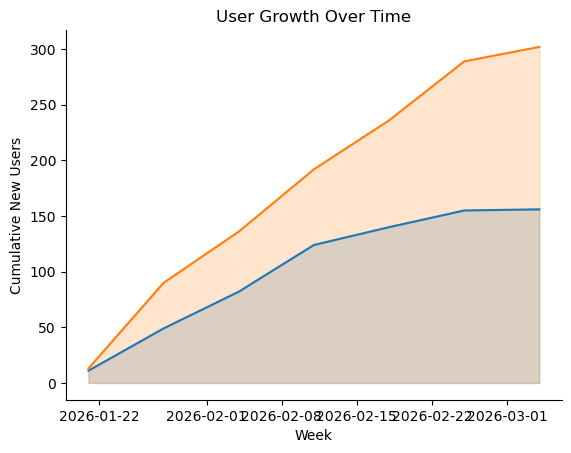

In [17]:
# TODO try and use the python GA API https://medium.com/@tmmylo1021/extract-google-analytics-data-with-python-221626ed8975

# data_ga = pandas.read_csv("View_user_engagement_and_retention_overview.csv")

# data_ga


def plot_new_users_over_time_tutorials(fill_between=True, **kwargs):
    start_date_ga =  datetime(2025, 12, 3)
    end_date_ga = datetime(2026, 3, 2)
    nth_week = [7, 8, 9, 10, 11, 12, 13]
    new_users = [11, 38, 33, 42, 16, 15, 1]

    new_users_cumulative = np.cumsum(new_users)

    # convert nth_week to datetime for plotting
    nth_week_dates = [start_date_ga + pd.Timedelta(weeks=n) for n in nth_week]
    (l,) = plt.plot(nth_week_dates, new_users_cumulative, **kwargs)
    if fill_between:
        plt.fill_between(
            nth_week_dates, new_users_cumulative, alpha=0.2, color=l.get_color()
        )
    return nth_week_dates, new_users_cumulative


def plot_new_users_over_time_docs(fill_between=True, **kwargs):
    start_date_ga =  datetime(2025, 12, 3)
    end_date_ga = datetime(2026, 3, 2)

    nth_week = [7, 8, 9, 10, 11, 12, 13]
    new_users = [13, 77, 46, 56, 44, 53, 13]

    new_users_cumulative = np.cumsum(new_users)

    # convert nth_week to datetime for plotting
    nth_week_dates = [start_date_ga + pd.Timedelta(weeks=n) for n in nth_week]
    (l,) = plt.plot(nth_week_dates, new_users_cumulative, **kwargs)
    if fill_between:
        plt.fill_between(
            nth_week_dates, new_users_cumulative, alpha=0.2, color=l.get_color()
        )
    return nth_week_dates, new_users_cumulative


plot_new_users_over_time_tutorials()
plot_new_users_over_time_docs()
plt.xlabel("Week")
plt.ylabel("Cumulative New Users")
plt.title("User Growth Over Time")
plt.show()


## GitHub contributors (main)

GITHUB_TOKEN not found in environment variables.
✅ Data ready!


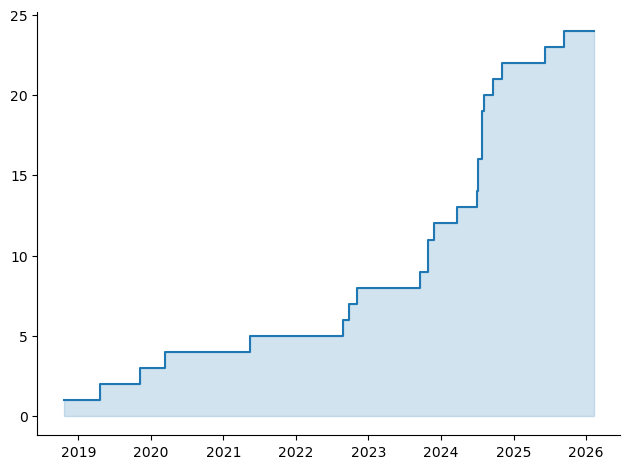

In [18]:
from get_contributors import fetch_contributor_stats

timeline = fetch_contributor_stats(OWNER, REPO)

def plot_contributor_stats(fill_between=True, **kwargs):
    dates = [entry["date"] for entry in timeline]
    cumulative_contributors = [entry["cumulative_contributors"] for entry in timeline]
    l, = plt.step(dates, cumulative_contributors, where="post", **kwargs)
    if fill_between:
        plt.fill_between(
            dates,
            cumulative_contributors,
            step="post",
            alpha=0.2,
            color=l.get_color(),
        )
    return dates, cumulative_contributors

plot_contributor_stats()

plt.tight_layout()
plt.show()

## Main figure

In [19]:
def extrapolate_data(xs, ys, future_date):
    # Fit a linear model to the existing data
    x = np.array([(date - xs[0]).days for date in xs])
    y = ys
    coeffs = np.polyfit(x, y, 1)  # Linear fit
    slope, intercept = coeffs

    # Extrapolate to the future date
    future_x = (future_date - xs[0]).days
    extrapolated_y = slope * future_x + intercept

    return extrapolated_y

In [42]:
def add_milestone(date, label, text_kwargs=None, line_kwargs=None, xytext=(0, 10), arrow=False):
    if text_kwargs is None:
        text_kwargs = {}
    if line_kwargs is None:
        line_kwargs = {}
    l = plt.axvline(x=date, **line_kwargs)
    # text above the line
    if arrow:
        arrowprops = dict(arrowstyle="-", color=l.get_color(), linestyle="dashed")
    else:
        arrowprops = None
    plt.annotate(label, xy=(date, 1), xytext=xytext, textcoords="offset points", ha="center", color=l.get_color(), arrowprops=arrowprops, **text_kwargs)
    return l

def add_period(start, end, label, text_kwargs=None, line_kwargs=None):
    if text_kwargs is None:
        text_kwargs = {}
    if line_kwargs is None:
        line_kwargs = {}
    plt.axvspan(start, end, alpha=0.3, **line_kwargs)
    plt.annotate(label, xy=((start + (end - start) / 2), 0.5), va="center", ha="center", **text_kwargs)

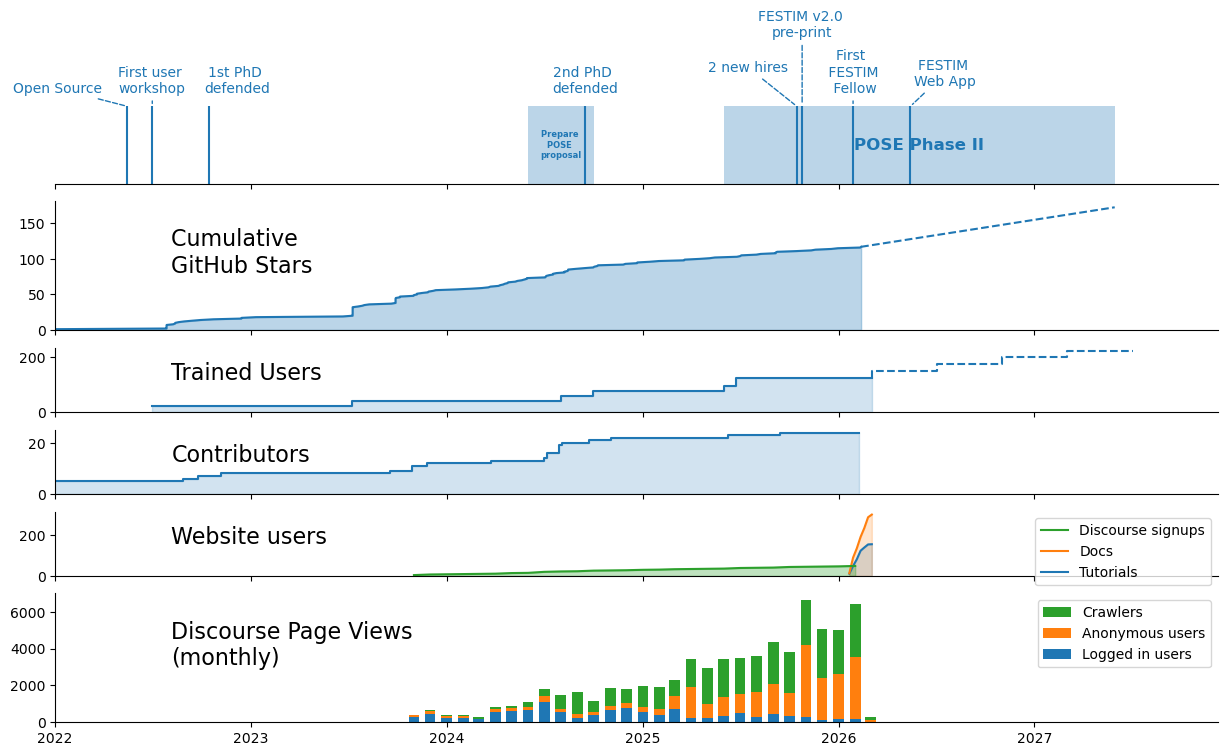

In [59]:
phase_ii_start = datetime(2025, 6, 1)
phase_ii_end = datetime(2027, 5, 31)

title_coords = (0.1, 0.6)

fig, axs = plt.subplots(
    nrows=6,
    ncols=1,
    sharex=True,
    figsize=(15, 8),
    height_ratios=[0.6, 1, 0.5, 0.5, 0.5, 1]
)



plt.sca(axs[1])
l = plot_star_history()
extrapolate_stars_nb = extrapolate_data(star_dates, cumulative_stars, phase_ii_end)
plt.plot([star_dates[-1], phase_ii_end], [cumulative_stars[-1], extrapolate_stars_nb], linestyle="--", color=l.get_color())
plt.annotate("Cumulative \nGitHub Stars", xy=title_coords, xycoords='axes fraction', va="center", fontsize=16)
plt.ylim(bottom=0)

plt.sca(axs[2])
workshop_dates, cumulative_trained_users = plot_trained_users_over_time(workshop_data)

# 3 workshops a year with ~25 ppls each
nb_workshops_per_year = 3
ppl_per_workshop = 25
new_workshop_dates = [workshop_dates[-1] + pd.Timedelta(days=365 * i / nb_workshops_per_year) for i in range(1, 5)]
new_cumulative_trained_users = cumulative_trained_users[-1] + np.arange(1, 5) * ppl_per_workshop

#add last point
new_workshop_dates.insert(0, workshop_dates[-1])
new_cumulative_trained_users = np.insert(new_cumulative_trained_users, 0, cumulative_trained_users[-1])
plt.step(new_workshop_dates, new_cumulative_trained_users, linestyle="--", color=l.get_color())

plt.annotate("Trained Users", xy=title_coords, xycoords='axes fraction', va="center", fontsize=16)
plt.ylim(bottom=0)

plt.sca(axs[3])

plot_contributor_stats()
plt.annotate("Contributors", xy=title_coords, xycoords='axes fraction', va="center", fontsize=16)
plt.ylim(bottom=0)

plt.sca(axs[4])
ga_users_dates, users_cumul = plot_new_users_over_time_tutorials(label="Tutorials")
plot_new_users_over_time_docs(label="Docs")
plot_signups(label="Discourse signups")
plt.annotate("Website users", xy=title_coords, xycoords='axes fraction', va="center", fontsize=16)
plt.legend(reverse=True)
plt.ylim(bottom=0)

plt.sca(axs[5])
plot_page_views(width=20)
plt.annotate("Discourse Page Views\n(monthly)", xy=title_coords, xycoords='axes fraction', va="center", fontsize=16)
plt.legend(reverse=True)
plt.ylim(bottom=0)

plt.sca(axs[0])

add_milestone(datetime(2022, 5, 15), "Open Source", xytext=(-50, 10), arrow=True)
add_milestone(datetime(2022, 10, 15), "1st PhD \ndefended", xytext=(20, 10))
add_milestone(datetime(2024, 9, 15), "2nd PhD \ndefended", xytext=(0, 10))
add_milestone(workshop_dates[0], "First user \nworkshop", xytext=(0, 10), arrow=True)
# add_milestone(ga_users_dates[0], "Google \nAnalytics", xytext=(-25, -25), arrow=True)
add_milestone(datetime(2026, 5, 15), "FESTIM \nWeb App", xytext=(25, 15), arrow=True)
add_milestone(datetime(2026, 1, 28), "First \n FESTIM \n Fellow", arrow=True)


add_period(datetime(2024, 6, 1), datetime(2024, 10, 1), label="Prepare \nPOSE \nproposal", text_kwargs={"color": "tab:blue", "weight": "bold", "fontsize": 6})

add_period(phase_ii_start, phase_ii_end, label="POSE Phase II", text_kwargs={"color": "tab:blue", "weight": "bold", "fontsize": 12})

add_milestone(datetime(2025, 10, 25), "FESTIM v2.0 \npre-print", xytext=(0, 50), arrow=True)
add_milestone(datetime(2025, 10, 15), "2 new hires", xytext=(-35, +25), arrow=True)


plt.gca().get_yaxis().set_visible(False)
plt.gca().spines["left"].set_visible(False)

plt.xlim(left=datetime(2022, 1, 1))

plt.show()